In [1]:
import math
from random import shuffle
from copy import deepcopy
import torch
import torch.nn.functional as tfunc
import matplotlib.pyplot as plt

torch_device = "cpu"
if torch.cuda.is_available():
    print("CUDA is available")
    torch_device = "cuda"
elif torch.backends.mps.is_available():
    print("MPS is available")
    torch_device = "mps"

torch.set_default_device(torch_device)

MPS is available


# Building Dataset

In [ ]:
msgs = open("../messages.txt", "r").read().split("\n---\n")
# Remove links(for now, will add later for more advanced models)
msgs = [msg for msg in msgs if not msg.startswith("https://")]
chars = sorted(list(set("".join(msgs))))
char_to_indx = {char: indx+2 for indx, char in enumerate(chars)}
char_to_indx["<S>"] = 0
char_to_indx["<E>"] = 1
indx_to_char = {indx: char for char, indx in char_to_indx.items()}

def train_dev_test_split(msgs, train_percentage, dev_percentage): # Test percentage is implied since this is a strict 3 way split
    shuffled_msgs = deepcopy(msgs)
    shuffle(shuffled_msgs)
    train_dev_split_point = math.ceil(len(msgs) * train_percentage)
    dev_val_split_point = math.floor(
        train_dev_split_point + (len(msgs) * dev_percentage)
    )
    return (
        shuffled_msgs[:train_dev_split_point],
        shuffled_msgs[train_dev_split_point:dev_val_split_point],
        shuffled_msgs[dev_val_split_point:],
    )

def create_dataset(sentences, char_to_indx, block_size = 3):
    # Replace all user mentions @{user.id} i.e. @8212341892348 with their username @{username} i.e. @noscoperkillstreak
    for idx in range(len(sentences)):

    # first_run = True
    inputs, labels = [], []
    for sentence in sentences:
        context = [0] * block_size
        for label in tuple(sentence) + ("<E>",):
            label_indx = char_to_indx[label]
            labels.append(label_indx)
            # if first_run:
            #     print("".join(indx_to_char[indx] for indx in context), "------>", label)

            context = context[1:] + [label_indx]
            inputs.append(context)

        # if first_run: print("="*(block_size*2))
        # first_run = False

    return torch.tensor(inputs), torch.tensor(labels)

BLOCK_SIZE = 128
train_words, dev_words, test_words = train_dev_test_split(msgs, 0.8, 0.1)
train_inputs, train_labels = create_dataset(train_words, char_to_indx, block_size=BLOCK_SIZE)
dev_inputs, dev_labels = create_dataset(dev_words, char_to_indx, block_size=BLOCK_SIZE)
test_inputs, test_labels = create_dataset(test_words, char_to_indx, block_size=BLOCK_SIZE)
print(train_inputs.shape)

torch.Size([301488, 128])


# Initializing Model Params

In [ ]:
# Params
gen = torch.Generator(device=torch_device).manual_seed(2147483647)
CHARS_NUM = len(chars)
EMBED_NUM = 256
HIDDEN_NUM = 2048
DOWN_SCALE_PARAMS = (0.8, 0.5, 0.1)

# Uniform configurable params
C = torch.randn((CHARS_NUM, EMBED_NUM), requires_grad=True) # Lookup table
weights1 = (torch.randn((BLOCK_SIZE * EMBED_NUM, HIDDEN_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[0]).detach().requires_grad_()
weights2 = (torch.randn((HIDDEN_NUM, CHARS_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[1]).detach().requires_grad_()
bias2 = (torch.randn(CHARS_NUM, requires_grad=True) * DOWN_SCALE_PARAMS[2]).detach().requires_grad_()

batch_norm_gain = torch.ones((1, HIDDEN_NUM), requires_grad=True)
batch_norm_bias = torch.zeros((1, HIDDEN_NUM), requires_grad=True)
batch_norm_running_mean = torch.zeros((1, HIDDEN_NUM))
batch_norm_running_std = torch.ones((1, HIDDEN_NUM))

parameters = [C, weights1, batch_norm_gain, batch_norm_bias, weights2, bias2]
print([param.shape for param in parameters])
print(f"TOTAL PARAMS: {sum([param.nelement() for param in parameters])}")

[torch.Size([201, 256]), torch.Size([32768, 2048]), torch.Size([2048, 201]), torch.Size([201]), torch.Size([1, 2048]), torch.Size([1, 2048])]
TOTAL PARAMS: 67576265


# Training Model

In [24]:
EPOCHS = 1000
MINI_BATCH_SIZE = 2000
LOG_EVERY = 1

losses = []
learning_rate = 0.1
for indx in range(0, EPOCHS):
    mini_batch_indxs = torch.randint(0, train_inputs.shape[0], (MINI_BATCH_SIZE,))
    mini_batch_inputs = train_inputs[mini_batch_indxs]
    mini_batch_labels = train_labels[mini_batch_indxs]

    embed = C[mini_batch_inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    current_mean, current_std = preact.mean(0, keepdim=True), preact.std(0, keepdim=True)
    batch_norm_preact = batch_norm_gain * ((preact - current_mean) / current_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, mini_batch_labels)

    with torch.no_grad():
        batch_norm_running_mean = 0.99 * batch_norm_running_mean + 0.01 * current_mean
        batch_norm_running_std = 0.99 * batch_norm_running_std + 0.01 * current_std

    for param in parameters:
        param.grad = None

    if indx < 2 * EPOCHS // 3: learning_rate = 0.01 
    loss.backward(retain_graph=True)
    for param in parameters:
        param.data += -learning_rate * param.grad
    
    if indx % LOG_EVERY == 100 print(f"{indx}/{EPOCHS} : {loss.item()}")
    losses.append(loss.log10().item())

0/1000 : 36.566917419433594
1/1000 : 35.80390548706055
2/1000 : 35.708534240722656
3/1000 : 36.703922271728516
4/1000 : 34.626930236816406
5/1000 : 34.69248962402344
6/1000 : 35.366764068603516
7/1000 : 34.640174865722656
8/1000 : 34.575740814208984
9/1000 : 34.973655700683594
10/1000 : 33.75764846801758
11/1000 : 33.904415130615234
12/1000 : 34.04890060424805
13/1000 : 34.2363166809082
14/1000 : 33.412628173828125
15/1000 : 34.01197814941406
16/1000 : 33.96034240722656
17/1000 : 32.97255325317383
18/1000 : 32.99899673461914
19/1000 : 32.030330657958984
20/1000 : 32.3636474609375
21/1000 : 32.781925201416016
22/1000 : 33.0929069519043
23/1000 : 31.94255828857422
24/1000 : 32.348480224609375
25/1000 : 31.58245277404785
26/1000 : 31.479190826416016
27/1000 : 31.13042640686035
28/1000 : 31.806625366210938
29/1000 : 31.821226119995117
30/1000 : 30.08370590209961
31/1000 : 31.564456939697266
32/1000 : 31.054241180419922
33/1000 : 30.862533569335938
34/1000 : 31.141132354736328
35/1000 : 30.

# Training loss curve plot

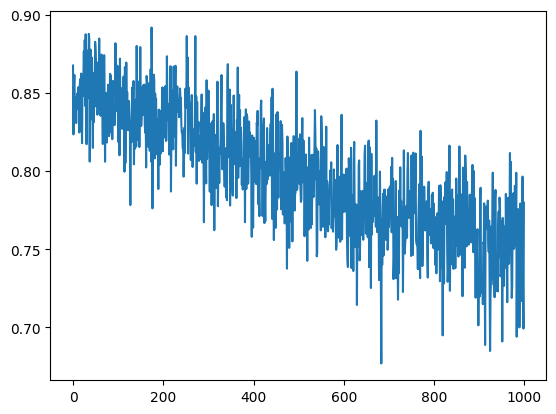

In [20]:
plt.plot(list(range(EPOCHS)), losses)

# Eval Model with Dev Data

In [25]:
@torch.no_grad()
def calc_loss(inputs, labels):
    embed = C[inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, labels)
    return loss

# Train and Dev are too big, they need to be chunked
BATCH_SIZE = 2056
m_train_loss = 0
for batch_idx in range(0, train_inputs.shape[0], BATCH_SIZE):
    end_idx = min(batch_idx + BATCH_SIZE, train_inputs.shape[0])
    batch_train_inputs = train_inputs[batch_idx:end_idx]
    batch_train_labels = train_labels[batch_idx:end_idx]
    m_train_loss += calc_loss(batch_train_inputs, batch_train_labels).item()
m_train_loss /= BATCH_SIZE

m_dev_loss = 0
for batch_idx in range(0, train_inputs.shape[0], BATCH_SIZE):
    end_idx = min(batch_idx + BATCH_SIZE, train_inputs.shape[0])
    batch_dev_inputs = train_inputs[batch_idx:]
    batch_dev_labels = train_labels[batch_idx:]
    m_dev_loss += calc_loss(batch_dev_inputs, batch_dev_labels).item()
m_dev_loss /= BATCH_SIZE

print(f"Test loss: {m_train_loss}")
print(f"Dev loss: {m_dev_loss}")

RuntimeError: Invalid buffer size: 36.56 GB

In [ ]:
# Best train loss: N/A
# Best dev loss: N/A

# Sample from the model

In [26]:
NUM_SAMPLES = 20
g = torch.Generator(device=torch_device).manual_seed(2147483647 + 10)
for _ in range(NUM_SAMPLES): 
    out = []
    context = [0] * BLOCK_SIZE
    while True:
        embed = C[torch.tensor([context])]
        joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
        preact = joined_embed @ weights1
        batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
        layer1_out = torch.tanh(batch_norm_preact)
        logits = layer1_out @ weights2 + bias2
        probs = tfunc.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
  
    print(''.join(indx_to_char[i] for i in out)) # decode and print the generated word

3pAAbbwww?vvvjf中lOObbuuuuuayfoii<E>drrp<E><E><E><E><E><E>ootttteeeeNttwiii‼eeefYanp,uurr,ooooofrf feeee\nvh           naa    ooo  llrrrc  b miiiimsssyaaussnooooooollliiiii<E>aal       nnnpggeeroooooohaaaaam <E><E>rattjho        sskdooovlrしoooee haaaellnnlwwwwdee  hui  hPioo’occ  ✅tnme      nntlleeeeasrhmmmouiiha本   nee   ls    asn gr gg—oooi    pll r   ww   tonbee tt会alreeyc☠Qly✅arriiidiit—ollttt.nssttwh^ioiewwsshheec   y,urrejgid/gr,ee🥹d   ossemtttteee   請hedvdlubdnnpagn  <E>✅ssgiiinn <E>nnndの      on繋 n-ere   ccn😔nooooh  tt"oihcmtaahlsssaao.oeeee. e"dfee    Tttss  iisswroup   oxmrrygghlee  d    ronnlftstntttnnnnt,laplllnndniplhchhhethh  idllh <E>csmaaem   otie$  thaaQgaprraa\v    eeltnuolttt🙇sso er  gnelwtrrhc,   ‍   ada  ssp  ato  sgreenneuulhww udch+ntnnnnra   tteeet   lwttsnnneiiate asdammssti/dttassaatthhieee,axuueeett^iimeetju   hhtttedectt  %iiiw@eeeecc  ehんrGcyymiunnn     ssaadn  p  stの   ccchoeaFhdaaafcnnnriakk<E>  abaatttliettt拶fh  ttvpeeeecnaaTwwtnnwccg中ahtf  afmloobuueee  

KeyboardInterrupt: 